# 6. Diferenciacion d1 d12 + modelo autorregresivo

Se elimina la tendencia (diferencia de orden 1) y el ciclo (diferencia de orden 12), se modela la serie resultante y despues se reconstruye el nivel.

In [1]:
%run functions.ipynb

In [2]:
df = load_data()
df = remove_trend_and_cycle(df)

plot_time_series(df[["yt_true_d1d12"]].dropna(), yt_col="yt_true_d1d12")

<Figure size 1200x400 with 1 Axes>

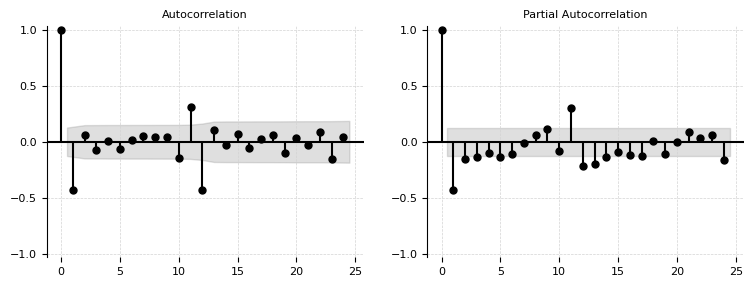

In [3]:
# La serie diferenciada ya no tiene tendencia; queda estructura en los rezagos 1 y 12

acf_pacf_plots(df.yt_true_d1d12.dropna())

In [4]:
from sklearn.linear_model import LinearRegression


def d1d12_forecast(y, p_max, n_test=24):
    """Pronostica el nivel a partir de un AR sobre la serie diferenciada.

    Reconstruccion: y_t = y_{t-1} + y_{t-12} - y_{t-13} + z_t. En
    entrenamiento se usan los valores reales; en prueba, los pronosticados.
    """

    y = np.asarray(y, dtype=float)
    z = pd.Series(y).diff(1).diff(12).values
    n_train = len(y) - n_test

    z_pred = recursive_forecast(LinearRegression(), z, p_max, n_test)

    history = list(y[:n_train])
    yt_pred = np.full(len(y), np.nan)

    for t in range(len(y)):
        if np.isnan(z_pred[t]):
            continue
        if t < n_train:
            yt_pred[t] = y[t - 1] + y[t - 12] - y[t - 13] + z_pred[t]
        else:
            history.append(history[-1] + history[-12] - history[-13] + z_pred[t])
            yt_pred[t] = history[-1]

    return yt_pred


# Seleccion del numero de rezagos con los ultimos 24 meses del entrenamiento
train = df.yt_true.iloc[:-24].values

validacion = {}

for p_max in (12, 13, 24, 36):
    forecast = d1d12_forecast(train, p_max)
    validacion[p_max] = np.mean(np.abs(train[-24:] - forecast[-24:]))

pd.Series(validacion, name="MAE validacion").round(1)

12    970.1
13    867.1
24    584.4
36    473.4
Name: MAE validacion, dtype: float64

P_MAX = 36


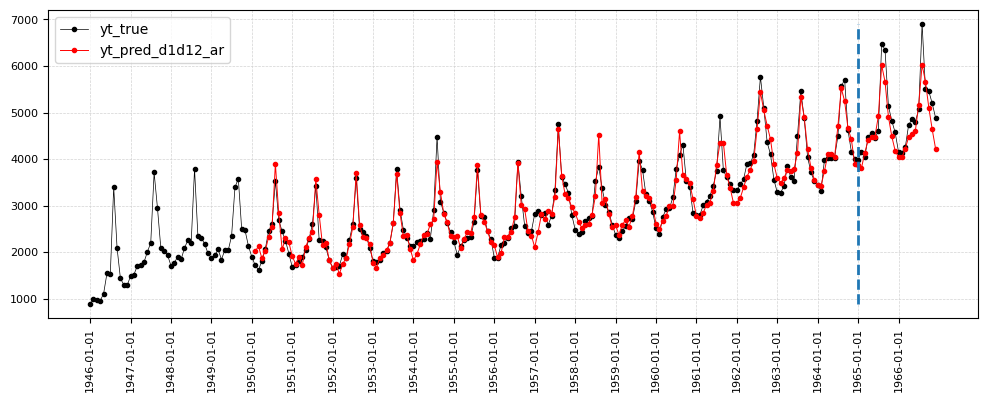

In [5]:
P_MAX = min(validacion, key=validacion.get)
print("P_MAX =", P_MAX)

df["yt_pred_d1d12_ar"] = d1d12_forecast(df.yt_true.values, P_MAX)

plot_time_series(df[["yt_true", "yt_pred_d1d12_ar"]])

In [6]:
metrics = compute_evaluation_metrics(df)
save_forecasts(df)
save_metrics(metrics)
metrics

,Metrics,yt_pred_d1d12_ar
0,MSE Train,46784.99
1,MSE Test,132232.41
2,MAE Train,159.49
3,MAE Test,286.58


Al quitar tendencia y ciclo, el modelo solo tiene que capturar las desviaciones. Mejora al SARIMA del notebook 8 y a Holt-Winters, pero no al autorregresivo directo del notebook 5: la reconstruccion acumula los errores del pronostico recursivo mes a mes.